<a href="https://colab.research.google.com/github/swatikeshri-2005/PCOS_health/blob/main/Fertility_Health_Dataset_Advanced_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("fertility_health_dataset.csv")


In [ ]:
df.head()

,Couple_ID,Female_Age,Male_Age,Female_BMI,Male_BMI,PCOS,Period_Regularity,Stress_Level,Sleep_Quality,Past_Pregnancies,Sperm_Count_M_per_mL,Sperm_Motility_Pct,Female_Smokes,Male_Smokes,Female_Alcohol,Male_Alcohol,Female_Exercise,Male_Exercise,Pregnancy_Success
0,CPL0001,26,28,21.1,30.1,No,Regular,5.4,6.1,1,21.6,81.0,No,Yes,Moderate,No_Alcohol,Light,No_Exercise,Failure
1,CPL0002,39,43,24.1,24.6,No,Regular,2.1,5.6,0,41.5,56.8,No,No,Low,High,Light,Active,Failure
2,CPL0003,34,41,25.4,25.9,Yes,Irregular,5.8,5.1,3,64.5,50.8,No,No,No_Alcohol,No_Alcohol,Light,No_Exercise,Success
3,CPL0004,30,33,28.7,30.1,No,Regular,7.2,4.9,2,80.2,46.6,No,No,Moderate,No_Alcohol,No_Exercise,Active,Success
4,CPL0005,27,31,25.1,22.7,Yes,Irregular,6.3,5.3,3,97.2,53.1,No,Yes,Low,Low,Active,Moderate,Failure


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Couple_ID             2000 non-null   object 
 1   Female_Age            2000 non-null   int64  
 2   Male_Age              2000 non-null   int64  
 3   Female_BMI            2000 non-null   float64
 4   Male_BMI              2000 non-null   float64
 5   PCOS                  2000 non-null   object 
 6   Period_Regularity     2000 non-null   object 
 7   Stress_Level          2000 non-null   float64
 8   Sleep_Quality         2000 non-null   float64
 9   Past_Pregnancies      2000 non-null   int64  
 10  Sperm_Count_M_per_mL  2000 non-null   float64
 11  Sperm_Motility_Pct    2000 non-null   float64
 12  Female_Smokes         2000 non-null   object 
 13  Male_Smokes           2000 non-null   object 
 14  Female_Alcohol        2000 non-null   object 
 15  Male_Alcohol         

In [ ]:
df.describe()

,Female_Age,Male_Age,Female_BMI,Male_BMI,Stress_Level,Sleep_Quality,Past_Pregnancies,Sperm_Count_M_per_mL,Sperm_Motility_Pct
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000
mean,32.537000,36.040000,23.975300,25.915550,4.973450,6.535650,0.776500,50.976150,55.23645
std,7.715594,8.033534,3.911116,4.326079,1.966938,1.768736,0.906619,19.793576,14.85918
min,20.000000,20.000000,16.000000,17.000000,1.000000,1.000000,0.000000,1.000000,12.00000
25%,26.000000,29.000000,21.200000,23.000000,3.600000,5.300000,0.000000,37.575000,44.97500
50%,33.000000,36.000000,24.000000,25.800000,5.000000,6.600000,1.000000,50.950000,54.90000
75%,39.000000,43.000000,26.700000,28.800000,6.300000,7.800000,1.000000,64.500000,65.20000
max,45.000000,52.000000,36.200000,39.900000,10.000000,10.000000,3.000000,120.000000,95.00000


In [ ]:
df.isnull().sum()

,0
Couple_ID,0
Female_Age,0
Male_Age,0
Female_BMI,0
Male_BMI,0
PCOS,0
Period_Regularity,0
Stress_Level,0
Sleep_Quality,0
Past_Pregnancies,0


In [ ]:
df.duplicated().sum()

np.int64(0)

EDA Visualizations

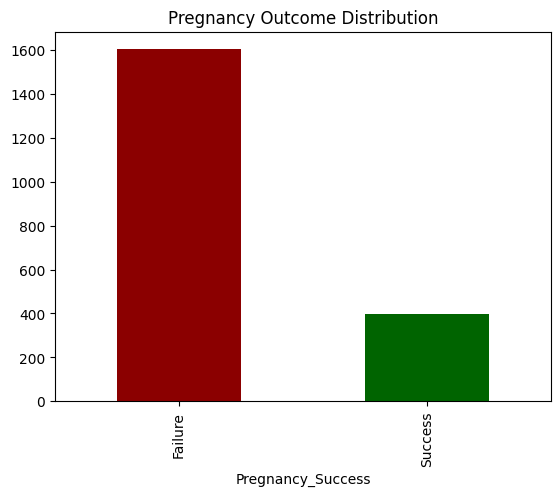

In [ ]:
df['Pregnancy_Success'].value_counts().plot(kind='bar',color=['darkred','darkgreen'])
plt.title('Pregnancy Outcome Distribution')
plt.show()

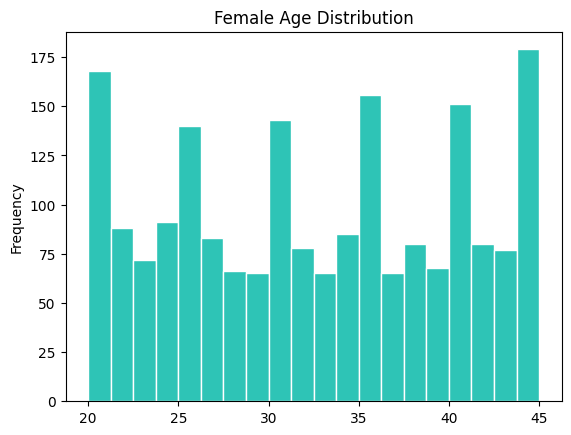

In [ ]:
df['Female_Age'].plot(kind='hist', bins=20,color='#2EC4B6', edgecolor='white')
plt.title('Female Age Distribution')
plt.show()

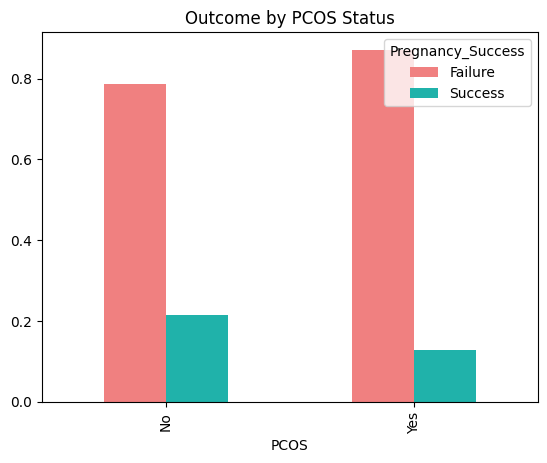

In [ ]:
df.groupby('PCOS')['Pregnancy_Success'].value_counts(normalize=True).unstack().plot(kind='bar',color=['lightcoral','lightseagreen'])
plt.title('Outcome by PCOS Status')
plt.show()

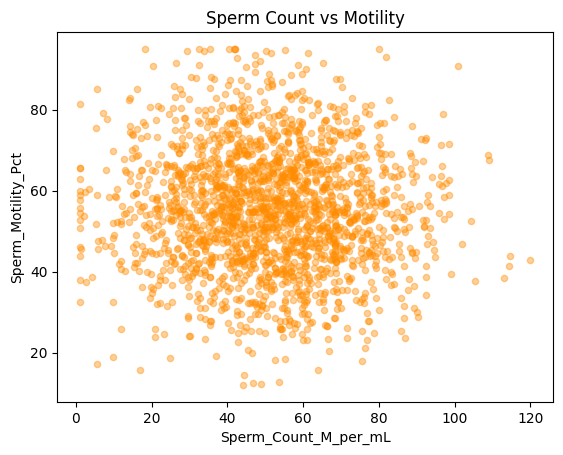

In [ ]:
df.plot.scatter(x='Sperm_Count_M_per_mL', y='Sperm_Motility_Pct', alpha=0.4,color='darkorange')
plt.title('Sperm Count vs Motility')
plt.show()

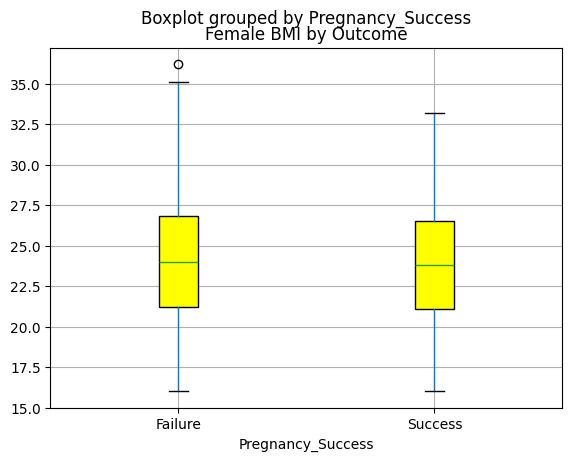

In [ ]:
df.boxplot(column='Female_BMI', by='Pregnancy_Success', patch_artist=True, boxprops=dict(facecolor='yellow'))
plt.title('Female BMI by Outcome')
plt.show()

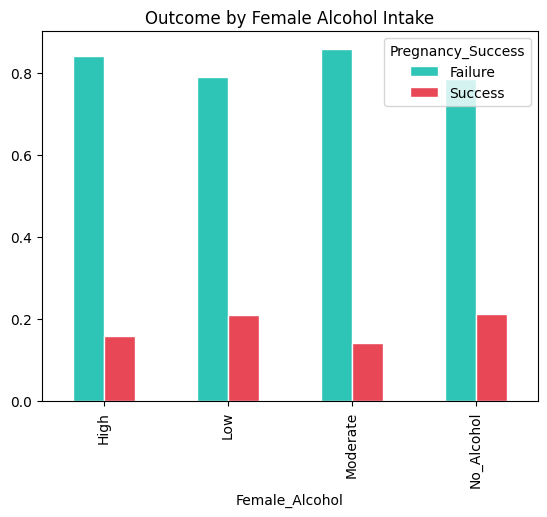

In [ ]:
colors = ['#2EC4B6', '#E84855']
df.groupby('Female_Alcohol')['Pregnancy_Success'].value_counts(normalize=True).unstack().plot(kind='bar',color=colors, edgecolor='white')
plt.title('Outcome by Female Alcohol Intake')
plt.show()

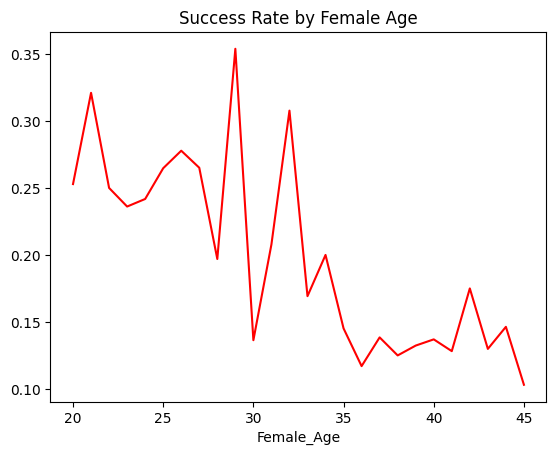

In [ ]:
df.groupby('Female_Age')['Pregnancy_Success'].apply(lambda x: (x=='Success').mean()).plot(color='red')
plt.title('Success Rate by Female Age')
plt.show()

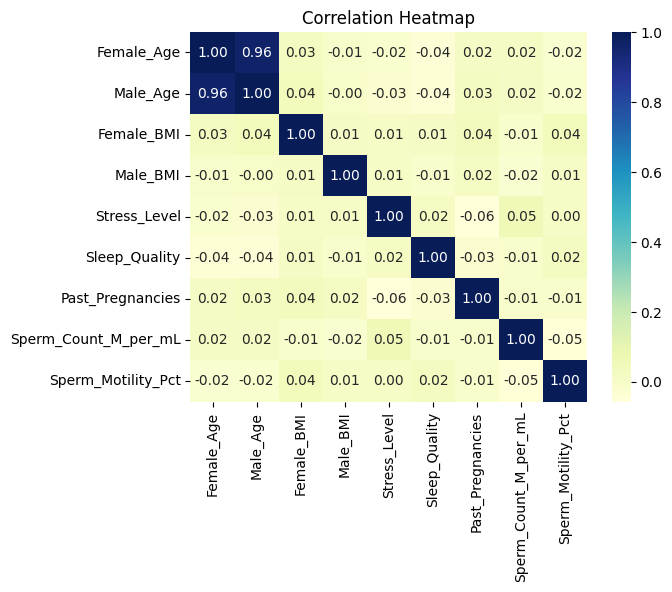

In [ ]:
import seaborn as sns
sns.heatmap(df.select_dtypes('number').corr(), annot=True, fmt = '.2f', cmap='YlGnBu')
plt.title('Correlation Heatmap')
plt.show()

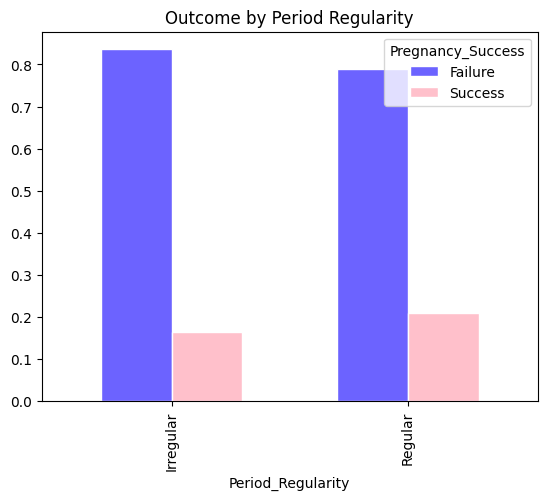

In [ ]:
colors = ['#6C63FF', 'pink']

df.groupby('Period_Regularity')['Pregnancy_Success'].value_counts(normalize=True).unstack().plot(
    kind='bar', color=colors, edgecolor='white', width=0.6
)

plt.title('Outcome by Period Regularity')
plt.show()

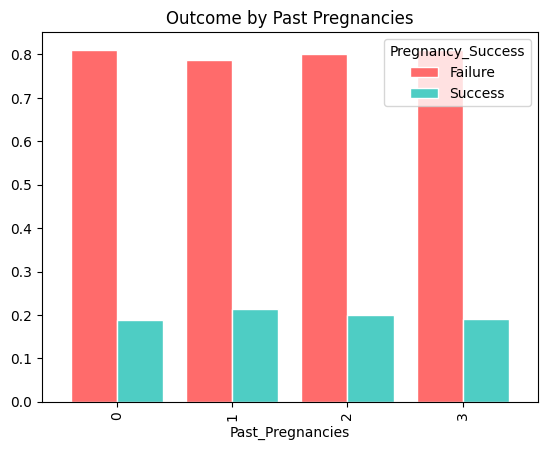

In [ ]:
colors = ['#FF6B6B', '#4ECDC4', '#FFE66D', '#A855F7']

df.groupby('Past_Pregnancies')['Pregnancy_Success'].value_counts(normalize=True).unstack().plot(
    kind='bar', color=colors, edgecolor='white', width=0.8
)

plt.title('Outcome by Past Pregnancies')
plt.show()

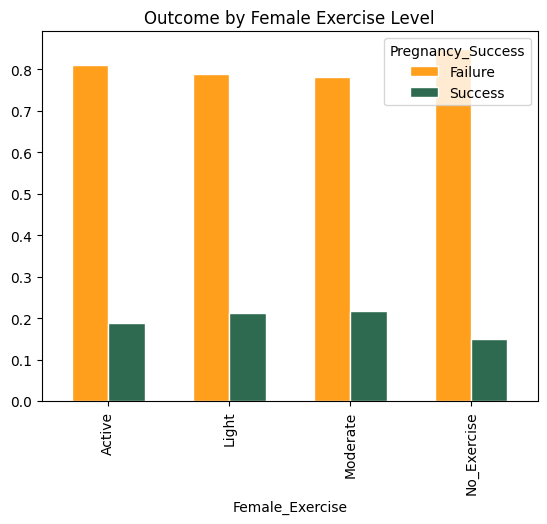

In [ ]:
colors = ['#FF9F1C', '#2D6A4F']

df.groupby('Female_Exercise')['Pregnancy_Success'].value_counts(normalize=True).unstack().plot(
    kind='bar', color=colors, edgecolor='white', width=0.6
)

plt.title('Outcome by Female Exercise Level')
plt.show()

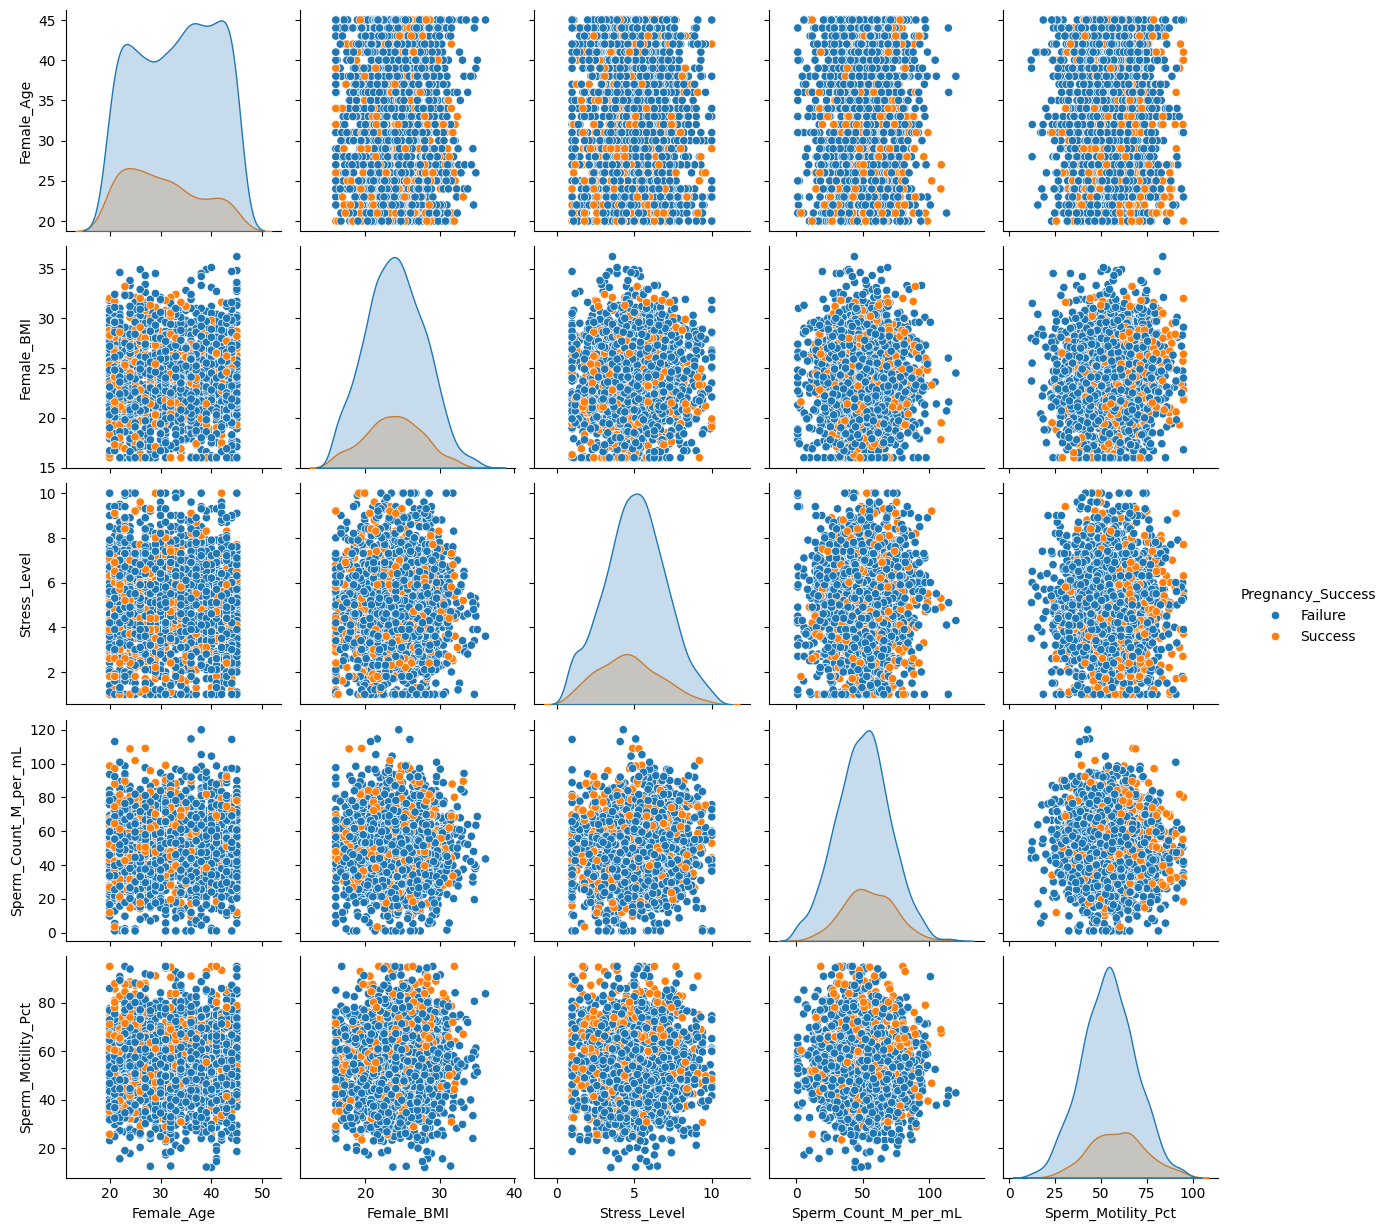

In [ ]:
import seaborn as sns
sns.pairplot(df[['Female_Age','Female_BMI','Stress_Level','Sperm_Count_M_per_mL','Sperm_Motility_Pct','Pregnancy_Success']], hue='Pregnancy_Success')
plt.show()